La question biologique centrale : 
La composition du microbiome intestinal reflète-t-elle la progression de la maladie hépatique, et quelles bactéries sont les biomarqueurs de chaque stade - santé, cirrhose, et encéphalohépathie hépatique? 

c'est quoi OTU = Operational Taxonomic Unit, c'est une unité de regroupement de séquences bactériennes 
Quand on séquence le microbiome intestinal, on omplifie un gène universel chez toutes les bactéries , le gène 16S rRNA, ce gène est présent chez toutes les bactéries mais avec des variations de séquence selon l'espèce. On obtient alors des millions de séquences d'ADN brutes. 

On ne pas comparer des séquences une par une une, il y en a trop et il y a des erreurs de séquençage. La solution c'est on regroupe les séquences similaires à 97% d'identié en clusters appelés OTUs, chaque OTU représente approximativement une espèce bactérienne 

RDP = Ribosomal Databse Project : c'est une base de données de l'Université de Michigan, contient des millions de séquences 16S rRNA de bactéries connues et classifiées 


In [1]:
# Chargement des données 
import requests
import tarfile
import os 


# Téléchargement depuis Zenodo :

url = "https://zenodo.org/records/569601/files/mhe_zhang_results.tar.gz?download=1"
r = requests.get(url, timeout=60)
if r.status_code==200:
    tar_path = "../data/cirrhose/mhe_zhang_results.tar.gz"
    with open(tar_path, "wb") as f: 
        f.write(r.content)
    print(f"Téléchargé:  {len(r.content) / 1e6:.1f} Mo")

    with tarfile.open(tar_path, "r:gz") as tar: 
        tar.extractall("../data/cirrhose/")
    print("Done")

    for root, dirs, files in os.walk("../data/cirrhose/"):
        for f in files:
            print(" ", os.path.join(root, f))
else:
    print(f"Erreur :  {r.status_code}")

Téléchargé:  0.3 Mo
Done
  ../data/cirrhose/mhe_zhang_results.tar.gz
  ../data/cirrhose/mhe_zhang_results/mhe_zhang.otu_table.100.denovo_oligotypes
  ../data/cirrhose/mhe_zhang_results/mhe_zhang.raw_dereplicated.fasta
  ../data/cirrhose/mhe_zhang_results/summary_file.txt
  ../data/cirrhose/mhe_zhang_results/mhe_zhang.otu_table.100.denovo
  ../data/cirrhose/mhe_zhang_results/mhe_zhang.otu_seqs.100.fasta
  ../data/cirrhose/mhe_zhang_results/mhe_zhang.metadata.txt
  ../data/cirrhose/mhe_zhang_results/quality_control/processing_summary.txt
  ../data/cirrhose/mhe_zhang_results/quality_control/sample_read_counts.png
  ../data/cirrhose/mhe_zhang_results/quality_control/read_lengths_distribution.png
  ../data/cirrhose/mhe_zhang_results/RDP/mhe_zhang.otu_table.100.denovo.rdp_assigned
  ../data/cirrhose/mhe_zhang_results/RDP/RDP_classifications.denovo.txt


Les fichiers générés sont les principales : 
- mhe_zhang.otu_table.100.denovo.rdp_assigned : la matrice principale : OTU avec noms taxonomique assigné par RDP , c'est la matrice d'abondance 
- mhe_zhang.metadata.txt : les métadonnées : statut clinique de chaque patient 
- RDP_classifications.denovo.txt : la classification taxonomique détaillée 

In [2]:
import pandas as pd 
import numpy as np 


meta = pd.read_csv("../data/cirrhose/mhe_zhang_results/mhe_zhang.metadata.txt", sep="\t", index_col=0)
print(f"Dimensions : {meta.shape}")
print(f"\nColonnes : {meta.columns.tolist()}")
print(f"\nAperçu :\n{meta.head()}")

otu = pd.read_csv(
    "../data/cirrhose/mhe_zhang_results/RDP/mhe_zhang.otu_table.100.denovo.rdp_assigned",
    sep="\t", index_col=0)

print(f"Dimensions : {otu.shape}")
print(f"\nAperçu (5 premières lignes, 5 premières colonnes) :")
print(otu.iloc[:5, :5])



Dimensions : (77, 25)

Colonnes : ['BioSample_s', 'Experiment_s', 'LoadDate_s', 'MBases_l', 'MBytes_l', 'Run_s', 'SRA_Sample_s', 'Assay_Type_s', 'AssemblyName_s', 'BioProject_s', 'Center_Name_s', 'Consent_s', 'InsertSize_l', 'LibraryLayout_s', 'LibrarySelection_s', 'LibrarySource_s', 'Library_Name_s', 'Organism_s', 'Platform_s', 'ReleaseDate_s', 'SRA_Study_s', 'g1k_analysis_group_s', 'g1k_pop_code_s', 'source_s', 'DiseaseState']

Aperçu :
                BioSample_s Experiment_s  LoadDate_s  MBases_l  MBytes_l  \
Sample_Name_s                                                              
C001           SAMN01163983    SRX185941  2012-09-10         2         6   
C002           SAMN01163984    SRX185942  2012-09-10         2         7   
C003           SAMN01163985    SRX185943  2012-09-10         3         9   
C004           SAMN01163986    SRX185944  2012-09-10         1         4   
C005           SAMN01163988    SRX185945  2012-09-10         0         1   

                   Run_s

In [3]:
# Distribution des groupes 

print(meta["DiseaseState"].value_counts())

X_raw = otu.T 
print(f"Dimensions : {X_raw.shape}")

# Aligner X et Y 
# S'assurer que l'ordre des échantillons est identique 

common = X_raw.index.intersection(meta.index)
print(f"\nÉchantillons communs X et meta : {len(common)}")

X_raw = X_raw.loc[common]
meta = meta.loc[common]
Y = meta["DiseaseState"]

print(Y.value_counts())

# Normalisation en abondances relatives 
X_relative  = X_raw.div(X_raw.sum(axis=1),axis=0)

print(f"Somme ligne 1 : {X_relative.iloc[0].sum():.4f}")
print(f"Somme ligne 2 : {X_relative.iloc[1].sum():.4f}")


DiseaseState
H       26
MHE     26
CIRR    25
Name: count, dtype: int64
Dimensions : (77, 3104)

Échantillons communs X et meta : 77
DiseaseState
H       26
MHE     26
CIRR    25
Name: count, dtype: int64
Somme ligne 1 : 1.0000
Somme ligne 2 : 1.0000


La prochaine étape est la filration des OTUs , pourquoi? 
si une bactérie est détectée chez seulement 2 patients sur 77. Que peut apprendre le modèle ML de cette bactérie ? Rien, parce qu'elle est absente chez 75 patients, donc sa valeur est 0 dans 97% des lignes. C'est un bruit statistique, pas signal biologique 

On garde uniquement les OTUs présents dans au moins 10% des échantillons, soit au moins 8 patient sur 77. Cela signifie que la bactérie est suffisamment répandue pour que le modèle puisse apprendre 

In [4]:
# Filtrage des OTUs présents dans moins de 10% des échantillons 
# Un OTU est "présent" si son abondance > 0 
# 10% de 77=7.7 -> on garde les OTUs présents chez au moins 8 patients 

prevalence = (X_relative > 0).sum(axis=0) / X_relative.shape[0]
seuil = 0.10
otus_gardes = prevalence[prevalence >= seuil].index


X_filtered = X_relative[otus_gardes]

print(f"OTUs avant filtrage : {X_relative.shape[1]}")
print(f"OTUs après filtrage : {X_filtered.shape[1]}")
print(f"OTUs supprimés      : {X_relative.shape[1] - X_filtered.shape[1]}")
print(f"\nDimensions finales  : {X_filtered.shape}")
print(f"Chaque ligne = un patient")
print(f"Chaque colonne = une bactérie présente dans au moins 10% des patients")

OTUs avant filtrage : 3104
OTUs après filtrage : 199
OTUs supprimés      : 2905

Dimensions finales  : (77, 199)
Chaque ligne = un patient
Chaque colonne = une bactérie présente dans au moins 10% des patients


La diversité Alpha (Shannon)
Pour rappel biologique : on s'attend à voir une diminution progressive de la diversité: Sains > Cirrhose > MHE. Si cette tendance existe, c'est notre première validation biologique 

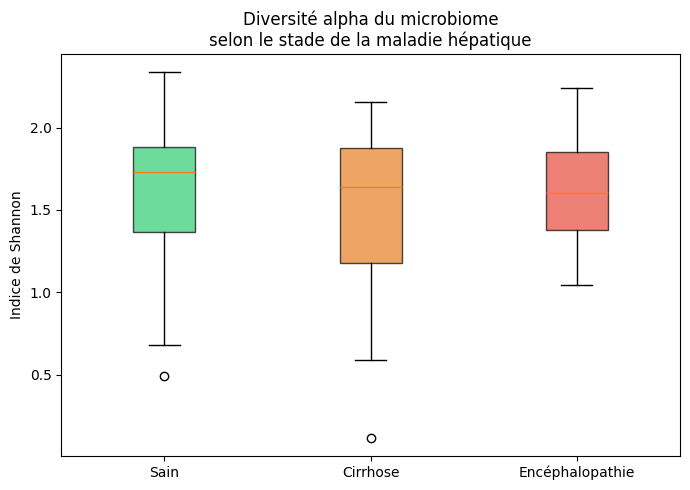

In [ ]:
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
from scipy import stats 
import numpy as np 


def Shannon(row):
    row = row[row > 0] 
    return -np.sum(row * np.log(row)) # C'est la formule mathématique Shannon = H = - Somme(pi x log(pi)) . Pour chaque bactérie on multiplie
                                      # on somme tout, et on met un signe négatif. 
                                      # Le signe négatif est là parce que log(pi) est toujours négatif (pi est entre 0 et 1), d
                                      # onc -log(pi) est positif - l'indice final est toujours positif.
shannon_div = X_filtered.apply(Shannon, axis=1)

div_df = pd.DataFrame({
    "shannon" : shannon_div,
    "DiseaseState": Y
})

# Paramètres de visualisation 

ordre = ["H", "CIRR", "MHE"]
labels = {"H": "Sain", "CIRR": "Cirrhose", "MHE": "Encéphalopathie"}
colors = {"H": "#2ECC71", "CIRR": "#E67E22", "MHE": "#E74C3C"}

fig, ax = plt.subplots(figsize=(7, 5))

data_plot = [div_df[div_df["DiseaseState"] == g]["shannon"].values
             for g in ordre]

bp = ax.boxplot(data_plot, patch_artist=True, positions=[0, 1, 2])

for patch, grp in zip(bp["boxes"], ordre):
    patch.set_facecolor(colors[grp])
    patch.set_alpha(0.7)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels([labels[g] for g in ordre])
ax.set_ylabel("Indice de Shannon")
ax.set_title("Diversité alpha du microbiome\nselon le stade de la maladie hépatique")

plt.tight_layout()
plt.savefig("../figures/shannon_diversity.png", dpi=150)

In [7]:
for grp in ordre:
    vals = div_df[div_df["DiseaseState"] == grp]["shannon"]
    print(f"Médiane {labels[grp]:15} : {vals.median():.3f}")

# Kruskal-Wallis 3 groupes
stat, p = stats.kruskal(*data_plot) # * décompresse une liste au lieu de passer [a,b] on passe à a,b 
print(f"\nKruskal-Wallis p-value : {p:.4f}")

# Tests pairés
pairs = [("H","CIRR"), ("CIRR","MHE"), ("H","MHE")]
for g1, g2 in pairs:
    v1 = div_df[div_df["DiseaseState"] == g1]["shannon"]
    v2 = div_df[div_df["DiseaseState"] == g2]["shannon"]
    _, p = stats.mannwhitneyu(v1, v2) # _ signfie on ignore la première valeur retournée on garde seulement p-value
    print(f"Mann-Whitney {labels[g1]} vs {labels[g2]:15} : p = {p:.4f}")

Médiane Sain            : 1.734
Médiane Cirrhose        : 1.641
Médiane Encéphalopathie : 1.601

Kruskal-Wallis p-value : 0.7040
Mann-Whitney Sain vs Cirrhose        : p = 0.4124
Mann-Whitney Cirrhose vs Encéphalopathie : p = 0.6043
Mann-Whitney Sain vs Encéphalopathie : p = 0.7767


Shanonn nous a donné un seul chiffre par patient , la diversité globale. Mais deux patients peuvent avoir le même indice Shannon avec des bactéries complètement différente. Shannon ne dit rien sur quelles bactéries sont présentes. 

C'est la raison pour laquelle on passe à la PCA, qui répond à une question différente: est ce que les patients cirrhotiques ont un microbiome globalement différent des patients sains, au niveau de la composition ? 

concrètement, chaque patient est un point dans un espace à 199 dimensions, une dimension par OTU , on ne peut pas visualiser 199 dimensions. La PCA compresse cet espace en 2 dimensions en gardant le maximum d'information possible, pour qu'on puisse voir si les groupes se séparent ou se mélangent. 

Si les 3 groupes forment des nuages séparés -> le microbiome encode le stade clinique 
Si les groupes se mélangent -> la variation inter-individuelle domine -> ML sera difficle mais pas impossible

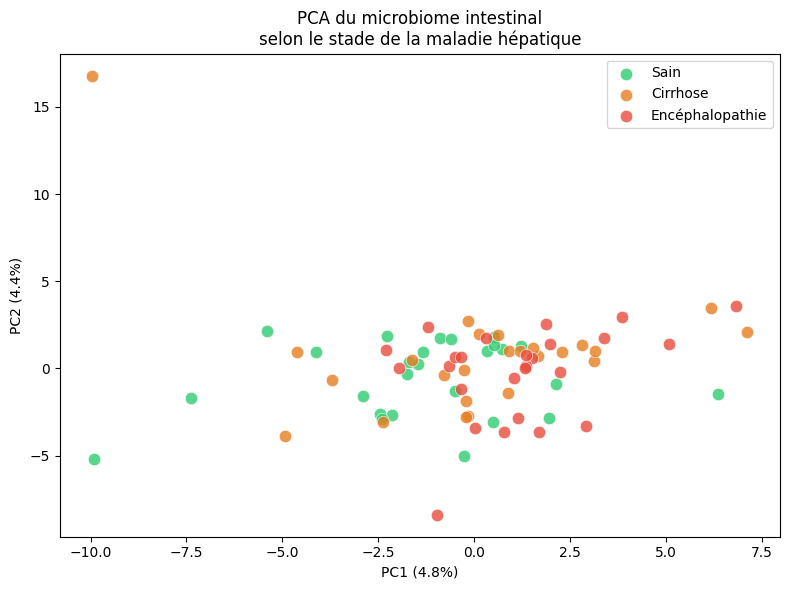

Variance PC1 : 4.8%
Variance PC2 : 4.4%


In [8]:
from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler # Outil de normalisation des données avant PCA


# Pourquoi standardiser avant PCA : 
# PCA sensible à l'échelle, si une bactérie a des abondances entre 0 et 0.5 et une autre 0 et 0.001 la pre
# première va dominer la PCA uniquement parce qu'elle a des valeurs plus grandes 
#

scaler = StandardScaler() # Transfome chaque colonne (chaque OTU ) pour avoir une moyenne de 0 et un écart type de 1 
X_scaled = scaler.fit_transform(X_filtered)



pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))

for grp in ordre:
    mask = Y.values == grp
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[grp], label=labels[grp],
               alpha=0.8, s=80, edgecolors="white", linewidths=0.5)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA du microbiome intestinal\nselon le stade de la maladie hépatique")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/pca_cirrhose.png", dpi=150)
plt.show()

print(f"Variance PC1 : {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variance PC2 : {pca.explained_variance_ratio_[1]*100:.1f}%")

Ce que PCA nous a appris biologiquement est que les groupes se chevauchent -> la variation inter-individuelle du microbiome est plus grande que la variation liée à la maladie. C'est normal et attendu. Deux personnes saines peuvent avoir des microbiomes très différents. C'est pour ça qu'on a besoin d'un algorithme qui travaille dans les 199 dimensions simultanément comme random Forest

La question biologique ici est : est-ce que la combinaison de plusieurs bactéries ensemble permet de prédire le stade clinique s'un patient? 

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

le = LabelEncoder()
y_encoded = le.fit_transform(Y)
print("Classes :", le.classes_)
print("Encodage :", dict(zip(le.classes_, le.transform(le.classes_))))


rf = RandomForestClassifier(
    n_estimators  = 500,
    random_state  = 42,
    class_weight  = "balanced"
)

# On divise les 77 patients en 5 groupes (folds) de presque 15 patients chacun.
# A chaque itération on entrâine sur 4 folds (62 patients) et 
# on teste sur 1 fold (15 patiens) on fais ça 5 fois


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


scores_acc = cross_val_score(rf, X_filtered, y_encoded, cv=cv, scoring="balanced_accuracy")
scores_f1  = cross_val_score(rf, X_filtered, y_encoded, cv=cv, scoring="f1_macro")

print("\n=== RÉSULTATS CROSS-VALIDATION (5 folds) ===")
print(f"Balanced Accuracy : {scores_acc.mean():.3f} ± {scores_acc.std():.3f}")
print(f"F1-score macro    : {scores_f1.mean():.3f} ± {scores_f1.std():.3f}")
print(f"\nDétail par fold accuracy : {scores_acc.round(3)}")

Classes : ['CIRR' 'H' 'MHE']
Encodage : {'CIRR': np.int64(0), 'H': np.int64(1), 'MHE': np.int64(2)}

=== RÉSULTATS CROSS-VALIDATION (5 folds) ===
Balanced Accuracy : 0.644 ± 0.164
F1-score macro    : 0.623 ± 0.189

Détail par fold accuracy : [0.756 0.867 0.4   0.667 0.533]


Modèle final entraîné sur 77 patients ✓


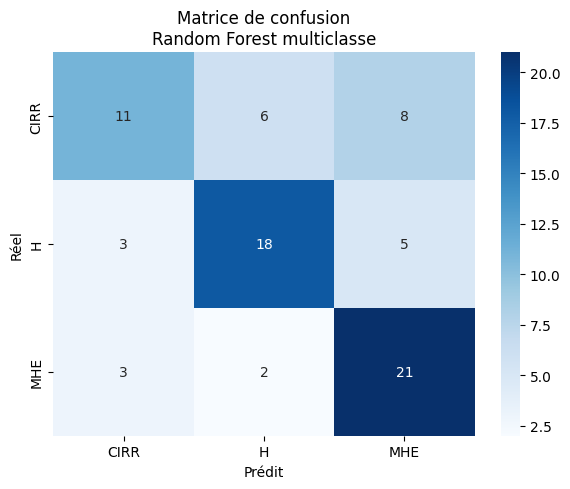

              precision    recall  f1-score   support

        CIRR       0.65      0.44      0.52        25
           H       0.69      0.69      0.69        26
         MHE       0.62      0.81      0.70        26

    accuracy                           0.65        77
   macro avg       0.65      0.65      0.64        77
weighted avg       0.65      0.65      0.64        77



In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Modèle final entraîné sur 100% des données 
# Pendant la cross-validation on entraînait sur 80% pour évaluer
# honnêtement. Maintenant on entraîne sur toutes les données
# pour maximiser l'apprentissage avant SHAP.
rf_final = RandomForestClassifier(
    n_estimators = 500,
    random_state = 42,
    class_weight = 'balanced'
)
rf_final.fit(X_filtered, y_encoded)
print('Modèle final entraîné sur 77 patients ')

#  Matrice de confusion via cross-validation 
# cross_val_predict retourne la prédiction de chaque patient
# quand il était dans le fold de test - évaluation honnête
y_pred = cross_val_predict(rf_final, X_filtered, y_encoded, cv=cv)
cm     = confusion_matrix(y_encoded, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
ax.set_title('Matrice de confusion\nRandom Forest multiclasse')
plt.tight_layout()
plt.savefig('../figures/confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_encoded, y_pred, target_names=le.classes_))


Le Random Forest prédit bien, mais c'est une boîte noire, il nous dit ce patient est cirrhotique sans expliquer pourquoi. En bioinformatique, l'explication est aussi importante que la prédiction, on veut savoir quelles bactéries ont poussé le modèle à prendre cette décision 

Le principe de SHAP : valeur de Shapley en théorie des jeux coopératifs. L'idée originale: dans une équipe qui gagne un prix, comment répartir équitablement le gain entre les joueurs selon leur contribution ? 

Transposé au ML : le "gain" c'est la prédiction du modèle, les "joueurs" ce sont les bactéries. SHAP demande : si j'enlève cette bactérie de l'information donnée au modèle, de combien la prédiction change-t-elle ?

Mais l'astuce de Shapley c'est qu'on ne teste pas juste "avec" et "sans" la bactérie. On teste toutes les combinaisons possibles de bactéries et on mesure la contribution marginale de chaque bactérie dans chaque coalition. Ça donne une valeur juste et non biaisée.

In [ ]:
import shap

#  Fonctions d'extraction taxonomique 
# Extraire le nom du genre et de la famille depuis le nom OTU complet
# Format : k__Bacteria;p__Firmicutes;...;g__Veillonella;s__;d__denovo17

def extraire_genre(nom_complet):
    for partie in nom_complet.split(';'):
        if 'g__' in partie:
            genre = partie.strip().replace('g__', '').split(' ')[0]
            return genre if genre else 'Inconnu'
    return 'Inconnu'

def extraire_famille(nom_complet):
    for partie in nom_complet.split(';'):
        if 'f__' in partie:
            famille = partie.strip().replace('f__', '').split(' ')[0]
            return famille if famille else 'Inconnu'
    return 'Inconnu'

def label_taxonomique(nom_complet):
    genre   = extraire_genre(nom_complet)
    famille = extraire_famille(nom_complet)
    return f'{genre} ({famille})' if genre != 'Inconnu' else f'Inconnu ({famille})'

# Calcul SHAP 
# TreeExplainer exploite la structure des arbres pour calculer
# les valeurs Shapley exactes - rapide et sans approximation
print('Calcul SHAP en cours...')
explainer   = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_filtered)
# shape : (77 patients, 199 OTUs, 3 classes)
print(f'Shape shap_values : {shap_values.shape}  ')

# SHAP global - top 20 toutes classes confondues 
# np.abs  -> amplitude de l'effet (positif ou négatif)
# .mean(axis=0)  -> moyenne sur les 77 patients  -> shape (199, 3)
# .mean(axis=1)  -> moyenne sur les 3 classes    -> shape (199,)
shap_global = np.abs(shap_values).mean(axis=0).mean(axis=1)

top20_idx    = np.argsort(shap_global)[::-1][:20]
top20_names  = X_filtered.columns[top20_idx]
top20_vals   = shap_global[top20_idx]
top20_labels = [label_taxonomique(n) for n in top20_names]

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(range(20), top20_vals[::-1], color='#3498DB', alpha=0.8)
ax.set_yticks(range(20))
ax.set_yticklabels(top20_labels[::-1], fontsize=9)
ax.set_xlabel('Importance SHAP moyenne')
ax.set_title('Top 20 bactéries biomarqueurs de la maladie hépatique\n(Random Forest + SHAP)')
plt.tight_layout()
plt.savefig('../figures/shap_global.png', dpi=150)
plt.show()

# SHAP par classe - top 10 par stade clinique 
# shap_values[:, :, i]  -> valeurs SHAP de la classe i
# shape : (77, 199)  -> .mean(axis=0)  -> (199,)
noms_classes     = ['Cirrhose', 'Sain', 'MHE']
couleurs_classes = ['#E67E22', '#2ECC71', '#E74C3C']

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for i, (nom, couleur) in enumerate(zip(noms_classes, couleurs_classes)):
    shap_classe  = np.abs(shap_values[:, :, i]).mean(axis=0)
    top10_idx_c  = np.argsort(shap_classe)[::-1][:10]
    top10_noms_c = X_filtered.columns[top10_idx_c]
    top10_vals_c = shap_classe[top10_idx_c]
    labels_c     = [label_taxonomique(n) for n in top10_noms_c]

    axes[i].barh(range(10), top10_vals_c[::-1], color=couleur, alpha=0.8)
    axes[i].set_yticks(range(10))
    axes[i].set_yticklabels(labels_c[::-1], fontsize=9)
    axes[i].set_title(f'Biomarqueurs\n{nom}', fontsize=11)
    axes[i].set_xlabel('Importance SHAP')

plt.suptitle('Biomarqueurs spécifiques par stade clinique', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/shap_par_classe.png', dpi=150, bbox_inches='tight')
plt.show()


## Interprétation biologique

Les biomarqueurs identifiés par SHAP sont en cohérence remarquable avec la physiopathologie connue de l'axe intestin-foie :

**🟠 Cirrhose** - *Veillonella* domine (SHAP = 0.033). Bactérie d'origine buccale, sa présence élevée confirme l'invasion oro-intestinale décrite par Qin et al. 2014 - 54% des espèces enrichies dans la cirrhose sont d'origine buccale.

**🟢 Sain** - *Lachnospiracea*, *Roseburia* et *Faecalibacterium* dominent. Ces 3 bactéries productrices de butyrate anti-inflammatoire caractérisent un intestin sain avec une barrière muqueuse intacte.

**🔴 MHE** - *Faecalibacterium* apparaît 3× dans le top 10. Son effondrement est le signal le plus fort de progression vers l'encéphalopathie - sans butyrate, la barrière intestinale s'effondre, l'ammoniaque produit par d'autres bactéries atteint le cerveau.

```
SAIN   ->  ↑ Lachnospiracea  ↑ Roseburia  ↑ Faecalibacterium
         Butyrate abondant  -> barrière intestinale intacte
              ↓ dysbiose progressive
CIRR   ->  ↑ Veillonella (invasion buccale)
         ↓ Lachnospiracea  ↓ Roseburia
         Barrière fragilisée  -> translocation bactérienne
              ↓ aggravation
MHE    ->  ↑↑ Veillonella
         ↓↓ Faecalibacterium (×3 dans SHAP)
         Effondrement butyrate  -> ammoniaque  -> encéphalopathie
```
